# Band usage development
Set up spectral fitting and localization using a Band object.


In [1]:
%reset -f
%run pylib/tools dark
from utilities.ipynb_docgen import show, capture_hide, show_date
from pylib.tools import np
from importlib import reload
from pylib.psf_func import PSFlist
from like3 import bands as b; reload(b)
from like3.bands import Band
from like3 import sourcelist as sl; reload(sl)
from like3.sourcelist import SourceModel, SourceModelException
from astropy.coordinates import SkyCoord
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-03-28 15:59</h5>

## Localization

Model: SourceModel: 2 sources with 4 free parameters


Band(energy=422.0 MeV, et=0 nside=64)

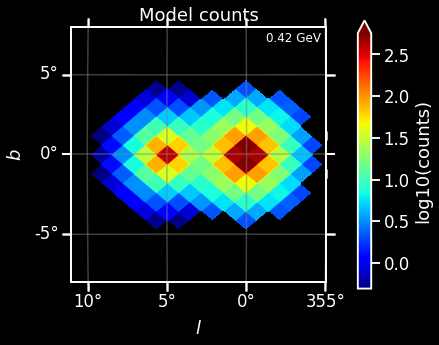

In [2]:
df = PSFlist.demo_df() 
source_model = sl.SourceModel.demo(3)
band = Band(df.iloc[2], source_model)
show(band)
band.plot_pixel_map((3,0),log=True, data=band.pixel_counts(), size=16, title='Model counts')

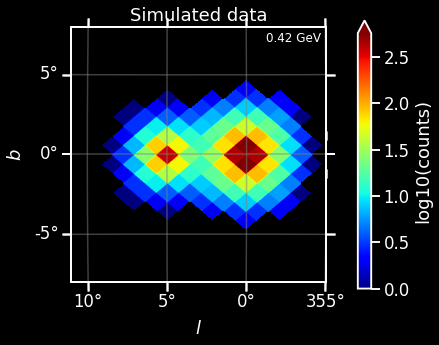

In [3]:
band.data = band.simulate()
band.plot_pixel_map((3,0), log=True, size=16, data=band.data, title='Simulated data')

### Loglike surface around each source position

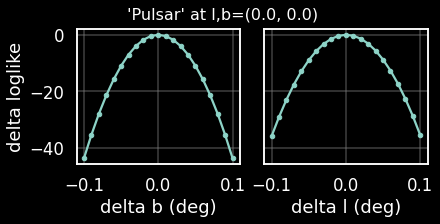

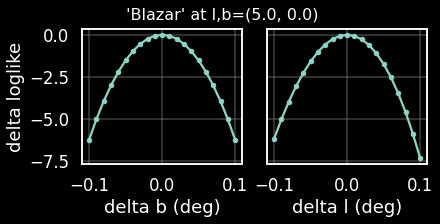

In [4]:
show(f"""### Loglike surface around each source position""")
for src in source_model: 
 
    l0, b0 = src.skydir.l.deg, src.skydir.b.deg
    llz = band.loglike()
    delta = np.linspace(-.1,.1, 21)        

    with source_model.localization_view(src.name):
     
        sll = SkyCoord(l0 + delta, b0, unit='deg', frame='galactic')
        sbb = SkyCoord(l0, b0 + delta, unit='deg', frame='galactic')
        
        yll = [band.loglike(x)-llz  for x in sll]
        ybb = [band.loglike(x)-llz  for x in sbb]

    fig, (ax1,ax2) = plt.subplots(1,2, figsize=(6,3),sharey=True)

    ax1.plot(delta, ybb, '.-')
    ax2.plot(delta, yll, '.-')
    ax1.set(xlabel='delta b (deg)', ylabel='delta loglike', )
    ax2.set_xlabel('delta l (deg)')
    fig.suptitle(f" '{src.name}' at l,b=({l0}, {b0})", fontsize=16);

### ΔTS on an (RA, Dec) grid around 'Blazar'

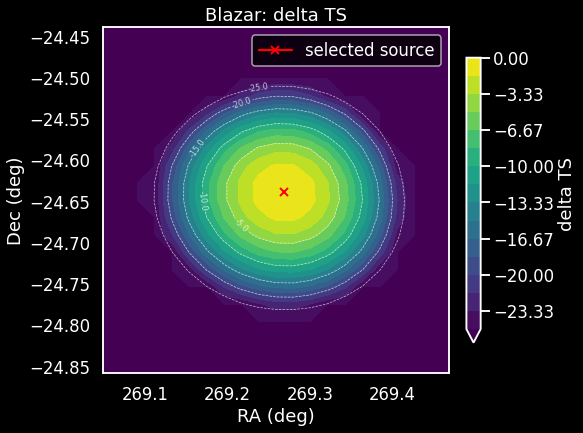

In [5]:
show(f"""### ΔTS on an (RA, Dec) grid around '{src.name}'""")
import matplotlib as mpl


ra0  = src.skydir.icrs.ra.deg
dec0 = src.skydir.icrs.dec.deg
llz  = band.loglike()

step  = 0.02        # degrees between grid points
n     = 21          # points per axis  -> +/-0.5 deg half-width
delta = np.linspace(-n // 2 * step, n // 2 * step, n)

ra_grid, dec_grid = np.meshgrid(ra0 + delta, dec0 + delta)

with source_model.localization_view(src.name):
    ll_grid = np.array([
        2 * (band.loglike(SkyCoord(ra, dec, unit='deg', frame='icrs')) - llz)
        for ra, dec in zip(ra_grid.ravel(), dec_grid.ravel())
    ]).reshape(n, n)


ts_min, ts_max = -25.0, 0.0
levels = np.linspace(ts_min, ts_max, 16)
ll_plot = np.clip(ll_grid, ts_min, ts_max)

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
cf = ax.contourf(ra_grid, dec_grid, ll_plot, levels=levels, 
                  cmap='viridis', #mpl.cm.hot_r, 
                  extend='min')
cs = ax.contour(ra_grid, dec_grid, ll_grid, levels=np.linspace(ts_min, ts_max, 6), colors='white', linewidths=0.7, alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
ax.plot(ra0, dec0, marker='x', color='red', ms=8, mew=2, label='selected source')
ax.set(xlabel='RA (deg)', ylabel='Dec (deg)', title=f"{src.name}: delta TS", aspect='equal')
ax.legend(loc='best')
fig.colorbar(cf, ax=ax, label='delta TS', shrink=0.5);

### Replot as sigma = sqrt(- TS)

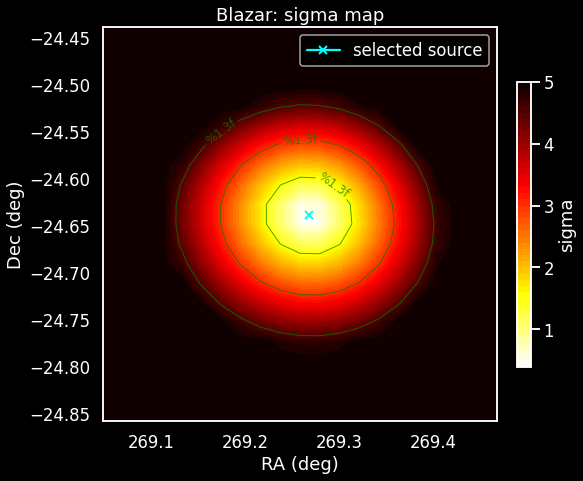

In [6]:
show(f"""### Replot as sigma = sqrt(- TS)""")

sigma_grid = np.sqrt(np.clip(-ll_grid, 0.0, 25))


cfmt={}
for key,t in zip(np.array([1.51, 2.45, 3.03]),['68%','95%', '99%']): 
    cfmt[key]=t

fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
levels_sigma = np.linspace(np.nanmin(sigma_grid), np.nanmax(sigma_grid), 16)
cf = ax.contourf(ra_grid, dec_grid, sigma_grid, levels=50,#levels=levels_sigma, 
                 cmap='hot_r')

cs = ax.contour(ra_grid, dec_grid, sigma_grid, levels=3, colors='green', linewidths=1, alpha=0.7)
ax.clabel(cs, fmt={1.51:'68%', 2.45:'95%', 3.03:'99%'}, 
          fontsize=12, inline=True)
# ax.clabel(cs, inline=True, fontsize=8, fmt='%.2f')

ax.plot(ra0, dec0, marker='x', color='cyan', ms=8, mew=2, label='selected source')
ax.set(xlabel='RA (deg)', ylabel='Dec (deg)', title=f"{src.name}: sigma map", aspect='equal')
ax.legend(loc='best')
fig.colorbar(cf, ax=ax, label='sigma', shrink=0.5, ticks=np.linspace(0, np.nanmax(sigma_grid), 6));

In [7]:
show(f"""### Example: LocalizedSourceView.delta_ts with band.loglike""")

from like3 import sourcelist as sl; reload(sl)

# Rebuild objects after reload so localization_view returns LocalizedSourceView.
source_model2 = sl.SourceModel.demo(3)
band2 = Band(df.iloc[2], source_model2)
band2.data = band.data
src2 = source_model2.find_source(src.name)
ra02 = src2.skydir.icrs.ra.deg
dec02 = src2.skydir.icrs.dec.deg

with source_model2.localization_view(src2.name) as loc:
    delta_ts = loc.delta_ts(band2.loglike)

    ts_at_selected = delta_ts(src2.skydir)
    trial = SkyCoord(ra02 + 0.05, dec02, unit='deg', frame='icrs')
    ts_at_trial = delta_ts(trial)

show(f"Selected source: {loc.source.name}")
show(f"TS at selected position: {ts_at_selected:.3f}")
show(f"TS at trial position (+0.05 deg in RA): {ts_at_trial:.3f}")

### Example: LocalizedSourceView.delta_ts with band.loglike

Model: SourceModel: 2 sources with 4 free parameters


Selected source: Blazar

TS at selected position: 0.000

TS at trial position (+0.05 deg in RA): -2.666

In [8]:
show(f"""### Example: Localization view with the BandList""")
from like3 import bands as b; reload(b)
from like3 import sourcelist as sl; reload(sl)
from like3.bands import BandList
bandlist = BandList(source_model, PSFlist.demo_df())
src = source_model.find_source('Blazar')
bandlist.simulate()
bandlist.loglike()

with bandlist.localization_view('Blazar') as loc:
    pos = loc.source.skydir;
    delta_ts = loc.delta_ts()  # returns callable
    ts_value = delta_ts(SkyCoord(5.01, 0.0, unit='deg', frame='galactic'))  # evaluates 2*(loglike(trial) - baseline)
    x,y,z = loc.make_grid(delta_ts, 0.03 )  # makes a grid of delta_ts values around the source position


### Example: Localization view with the BandList

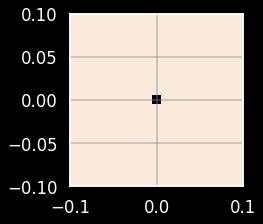

In [9]:
plt.imshow(np.sqrt((-z).clip(0,25)), origin='lower', extent=(-0.1, 0.1, -0.1, 0.1), interpolation='nearest');

In [10]:
from like3 import quadform; reload(quadform)
from like3.quadform import Localize, tests
tests()
# qf = QuadForm(sbb.deg, [loglike(self, PointSource(name='', skydir=skydir, model=test.model))-z0 for skydir in s
# with bandlist.localization_view('Blazar') as loc:
#     pos = loc.source.skydir
#     delta_ts = loc.delta_ts()
#     Localize(loc, pos, delta_ts)

testing with quad pars= [1, 0, 2.0, 0, 1, 0]
fit chisq, check:      7e-30      8e-31
elliptical pars:      1.123     0.673    -1.178     0.000    -0.000    -0.000
compare two functions:      3e-30
testing with quad pars= [2, 0, 1.0, 0, 1, 0]
fit chisq, check:      7e-30      8e-31
elliptical pars:      1.123     0.673    -0.393    -0.000     0.000     0.000
compare two functions:      1e-29
testing with quad pars= [1, 1, 1, 1, 1, 1]
fit chisq, check:      3e-30      9e-30
elliptical pars:      1.414     0.816    -0.785    -0.333    -0.333     0.667
compare two functions:      4e-30
testing with quad pars= [9.0, 0, 9.0, 0, 0, 0]
fit chisq, check:      3e-29      3e-30
elliptical pars:      0.333     0.333    -0.785    -0.000     0.000    -0.000
compare two functions:      2e-29


In [17]:
from like3 import quadform; reload(quadform)
from like3.quadform import Localize

# BandListLocalizationView now provides enough information for Localize directly:
# - loc.skydir gives the current source position
# - loc.delta_ts() returns a callable on SkyCoord trial positions
with bandlist.localization_view('Blazar') as loc:
    result = Localize(loc, sigma=0.05, verbose=True)
    print(f"Fitted position: ra={result.ra:.4f}  dec={result.dec:.4f}  sigma={result.sigma:.4f} deg")

initial: ra,dec, sigma:  269.2686  -24.6384    0.0500
ts:       -0.00   -645.80   -624.96   -603.54   -612.75   -631.87   -665.04   -675.36   -657.15
resid:    -0.00     -2.30     -0.63      3.44     -4.47      3.14     -0.20     -2.60      3.64
fit:       0.04     0.04    -0.82    -0.00     0.03    -0.43
chisq:     67.44
update:  ra,dec, sigma:  269.2682  -24.6352    0.0049
Fitted position: ra=269.2682  dec=-24.6352  sigma=0.0049 deg


In [ ]:
loc.skydir

AttributeError: 'SourceModel' object has no attribute 'skydir'

In [ ]:
sd = SourceModel.demo()
for s in sd:
    show(s)

Model: SourceModel: 2 sources with 4 free parameters


like3.sources.PointSource: 
	name  : Pulsar
	icrs  : (266.405, -28.936)
	model : PLSuperExpCutoff4
		Norm      : 1e-11 
		Index     : 2 
		Curvature : 0.7 (FROZEN)
		b         : 0.69 (FROZEN)

like3.sources.PointSource: 
	name  : Blazar
	icrs  : (269.269, -24.638)
	model : LogParabola
		Norm      : 4e-12 
		Index     : 2 
		beta      : 0 (FROZEN)
		E_break   : 1e+03 (FROZEN)

In [ ]:
g = band.pixel_gradient(band.data)
g.shape

(109, 4)

## Spectral fitting
Needs multiple bands, of course

### Create a Demosource_model with a pulsar and/or a blazar 

Model: SourceModel: 2 sources with 5 free parameters 12 pixels


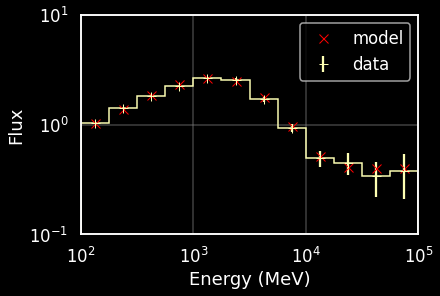

### Use Likelihood framework to fit the model to the data

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x72be6d3a3ac0>

In [ ]:
show(f"""### Create a Demosource_model with a pulsar and/or a blazar """)
from like3 import likelihood as lk; reload(lk)
from like3 import demo_model as dm; reload(dm)
model = dm.DemoModel.test(plot=True, src_key=2, random_state=42)

show(f""" ### Use Likelihood framework to fit the model to the data""")
with capture_hide('Fit summary') as cap:
    model = lk.Likelihood(model=model, data=model.data)
    print(model.model[0].model)
    model.maximize()
    model.summary()
    print(model.model[0].model)
show(cap)
# print('Previous one bin per band:', model.counts().astype(int))
